100%|██████████| 9.91M/9.91M [00:01<00:00, 5.77MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 151kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.34MB/s]


Epoch 1, Loss: 12215.5361328125
Epoch 2, Loss: 11216.9833984375
Epoch 3, Loss: 10877.5712890625


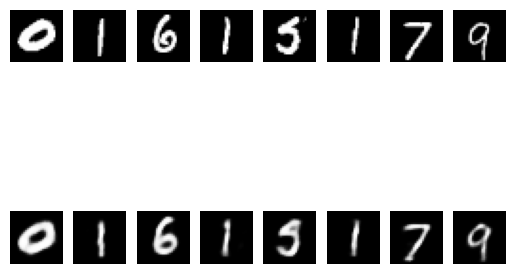

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Load MNIST
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True)

# VAE Model
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 20)
        self.fc22 = nn.Linear(400, 20)
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc21(h), self.fc22(h)

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Loss
def loss_fn(recon, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Train
for epoch in range(3):
    for x, _ in train_loader:
        x = x.view(-1, 784)
        recon, mu, logvar = model(x)
        loss = loss_fn(recon, x, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

# Visualization
with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, 784)
    recon, _, _ = model(x)

    fig, ax = plt.subplots(2, 8)
    for i in range(8):
        ax[0,i].imshow(x[i].view(28,28), cmap='gray')
        ax[1,i].imshow(recon[i].view(28,28), cmap='gray')
        ax[0,i].axis('off')
        ax[1,i].axis('off')
    plt.show()

Epoch 1
Epoch 2
Epoch 3


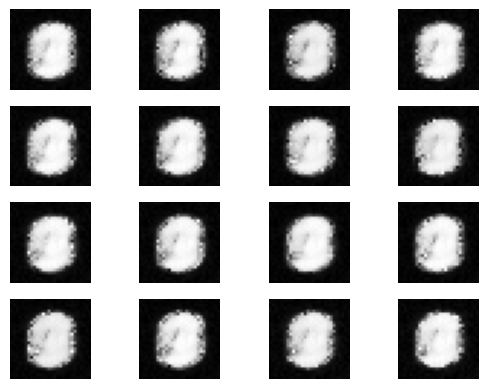

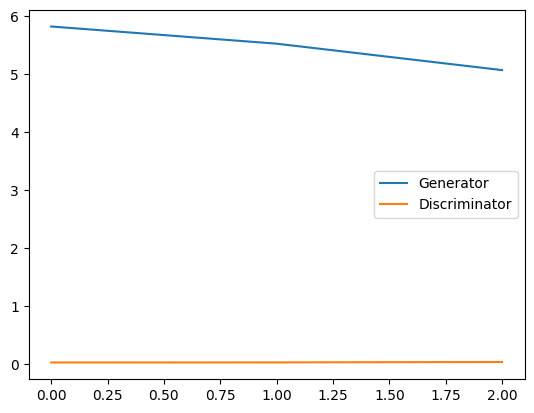

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(100, 784)

    def forward(self, x):
        return torch.sigmoid(self.fc(x))

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(784, 1)

    def forward(self, x):
        return torch.sigmoid(self.fc(x))

G = Generator()
D = Discriminator()

loss_fn = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.001)
opt_D = optim.Adam(D.parameters(), lr=0.001)

G_losses, D_losses = [], []

for epoch in range(3):
    for real, _ in train_loader:
        real = real.view(-1, 784)

        # Train Discriminator
        noise = torch.randn(real.size(0), 100)
        fake = G(noise)

        loss_D = loss_fn(D(real), torch.ones(real.size(0),1)) + \
                 loss_fn(D(fake.detach()), torch.zeros(real.size(0),1))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        loss_G = loss_fn(D(fake), torch.ones(real.size(0),1))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    G_losses.append(loss_G.item())
    D_losses.append(loss_D.item())
    print(f"Epoch {epoch+1}")

# Show generated images
noise = torch.randn(16, 100)
fake = G(noise).detach()

fig, ax = plt.subplots(4,4)
for i in range(16):
    ax[i//4, i%4].imshow(fake[i].view(28,28), cmap='gray')
    ax[i//4, i%4].axis('off')
plt.show()

# Loss graph
plt.plot(G_losses, label='Generator')
plt.plot(D_losses, label='Discriminator')
plt.legend()
plt.show()

In [ ]:
import torch
print(torch.__version__)

2.10.0+cpu


In [ ]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.10.0+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.10.0+cpu.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.10.0+cpu.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.10.0+cpu.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 8.8 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.6 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 10.6 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 807.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.7 MB/s eta 0:00:00


Processing...
Done!


Epoch 0, Loss 1.950583815574646
Epoch 10, Loss 0.6492498517036438
Epoch 20, Loss 0.14118753373622894
Epoch 30, Loss 0.03270026296377182
Epoch 40, Loss 0.01185967680066824


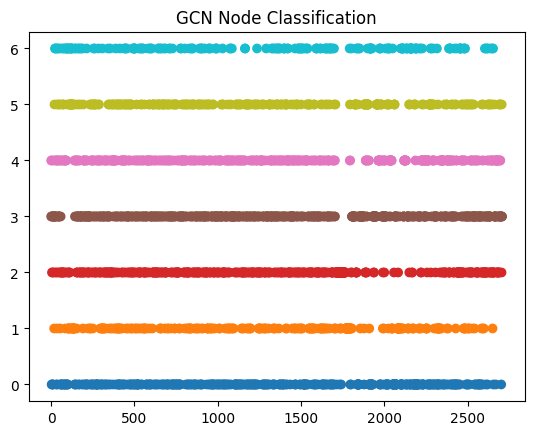

In [ ]:
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x

model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train
for epoch in range(50):
    out = model(data.x, data.edge_index)
    loss = torch.nn.functional.cross_entropy(out[data.train_mask], data.y[data.train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss {loss.item()}")

# Visualization
pred = model(data.x, data.edge_index).argmax(dim=1)

plt.scatter(range(len(pred)), pred.numpy(), c=pred.numpy(), cmap='tab10')
plt.title("GCN Node Classification")
plt.show()